## import libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

set general styling for visualization

In [39]:
sns.set_style("whitegrid")
sns.set_palette("Set2")  
plt.rcParams['figure.figsize'] = (10,6)

## load data file

In [2]:
df= pd.read_csv('OnlineRetail.csv', encoding='latin1')

## Exploratory Data Analysis (EDA) /Discover data

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## data cleaning
check and treat null values

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

drop null values

In [5]:
df=df.dropna(subset=['CustomerID','InvoiceDate'])

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

remove cancelled transactions

In [7]:
df=df[~df['InvoiceNo'].str.startswith('c')]

remove negative values

In [8]:
df=df[df['Quantity']>0 & (df['UnitPrice']>0)]

convert date column type to date

In [9]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'], errors='coerce')

convert customer id column type to integer

In [10]:
df['CustomerID'] = df['CustomerID'].astype(int)

remove duplicat values

In [11]:
df=df.drop_duplicates()

add total column

In [12]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850,United Kingdom,20.34


## create RFM Feature
RFM analysis is used to evaluate customer behavior based on:
- Recency: How recently a customer purchased
- Frequency: How often they purchase
- Monetary: How much they spend

refernce date(analysis date or today)

In [14]:
refrence_date=df['InvoiceDate'].max() + pd.Timedelta(days=1)
refrence_date

Timestamp('2011-12-11 17:19:00')

calculat recency,ferqurncy,monedary by customer id 

In [15]:
RFM=df.groupby('CustomerID').agg({'InvoiceDate': lambda x: (refrence_date - x.max()).days,
                                  'InvoiceNo': 'count',
                                  'TotalPrice': 'sum'})


In [16]:
RFM.columns = ['Recency', 'Frequency', 'Monetary']
RFM

,Recency,Frequency,Monetary
CustomerID,,,
12346,NaN,1,77183.60
12347,96.0,182,4310.00
12348,221.0,31,1797.24
12349,NaN,73,1757.55
12350,312.0,17,334.40
...,...,...,...
18280,161.0,10,180.60
18281,5.0,7,80.82
18282,217.0,12,178.05


make RFM copy to forces pandas to treat it as independent dataframe to avoid warning because of pandas confusing between view and full copy advancly

In [36]:
RFM = RFM.copy()

In [17]:
df['InvoiceDate'].isna().sum()

np.int64(226350)

In [18]:
RFM.isnull().sum()

Recency      1342
Frequency       0
Monetary        0
dtype: int64

In [19]:
RFM = RFM.dropna()

In [20]:
RFM.isna().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [21]:
Recency_Max=RFM['Recency'].max()
Recency_Min=RFM['Recency'].min()
Frequency_Max=RFM['Frequency'].max()
Frequency_Min=RFM['Frequency'].min()
Monetary_Max=RFM['Monetary'].max()
Monetary_Min=RFM['Monetary'].min()


check RFM ranges

In [22]:
print("Recency_Min:", Recency_Min)
print("Recency_Max:", Recency_Max)
print("Frequency_Min:", Frequency_Min)
print("Frequency_Max:", Frequency_Max)
print("Monetary_Min:", Monetary_Min)
print("Monetary_Max:", Monetary_Max)

Recency_Min: 1.0
Recency_Max: 698.0
Frequency_Min: 1
Frequency_Max: 7676
Monetary_Min: 6.2
Monetary_Max: 280206.02


 ## Data Scaling
 scale RFM(make R,F and M same scale and importance )

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

apply fit-transform /fit to learns mean & std transform to scales data

In [25]:
RFM_Scaled=scaler.fit_transform(RFM) 

In [26]:
print(type(RFM_Scaled))

<class 'numpy.ndarray'>


## K-Means Clustering
Group similar customers together (Kmeans)/Groups based on math

In [27]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
RFM_Scaled = scaler.fit_transform(RFM)

# KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)

create column cluster with apply fit_predict

In [37]:
RFM['cluster'] = kmeans.fit_predict(RFM_Scaled)

In [29]:
RFM.groupby('cluster').mean()

,Recency,Frequency,Monetary
cluster,,,
0,85.440566,125.161321,2655.999921
1,328.858796,52.123843,919.774317
2,12.500000,4652.500000,59192.981667
3,38.000000,846.285714,176559.085714


### Cluster Understanding
- Cluster 0: High recency and low activity so Lost customers
- Cluster 1: Average behavior so Regular customers
- Cluster 2: Low recency, high frequency and monetary so VIP customers
- Cluster 3: High spending but less frequent so High value customers

In [38]:
def classify(x):
    if x['cluster'] == 2:
        return "VIP"
    elif x['cluster'] == 3:
        return "High Value"
    elif x['cluster'] == 1:
        return "Regular"
    else:
        return "Lost"

RFM['Segment'] = RFM.apply(classify, axis=1)

In [31]:
RFM.head(20)

,Recency,Frequency,Monetary,cluster,Segment
CustomerID,,,,,
12347,96.0,182,4310.00,0,Lost
12348,221.0,31,1797.24,1,Regular
12350,312.0,17,334.40,1,Regular
12352,275.0,85,2506.04,1,Regular
12355,97.0,13,459.40,0,Lost
12356,129.0,59,2811.43,0,Lost
12357,183.0,131,6207.67,0,Lost
12358,4.0,19,1168.06,0,Lost
12359,10.0,245,6310.03,0,Lost


In [32]:
RFM.value_counts('Segment')

Segment
Lost          2120
Regular        864
High Value       7
VIP              6
Name: count, dtype: int64

## Cluster Analysis

Customer Segmentation

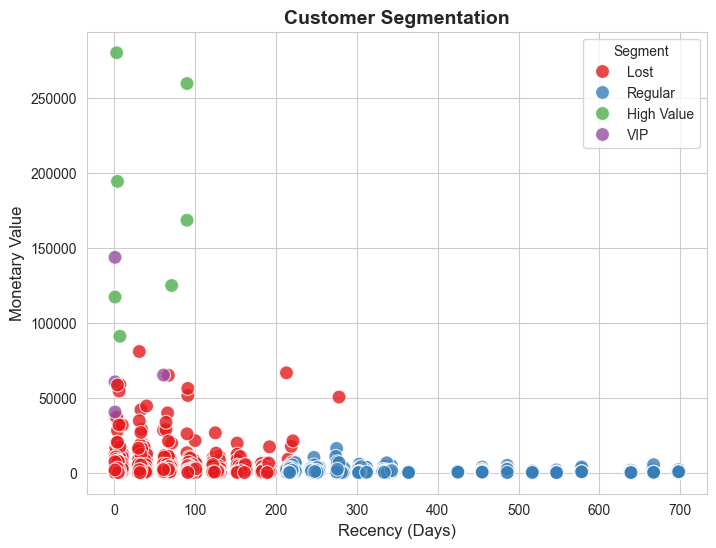

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=RFM,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='Set1',  
    s=100,            
    alpha=0.8)
plt.title("Customer Segmentation", fontsize=14, weight='bold')
plt.xlabel("Recency (Days)", fontsize=12)
plt.ylabel("Monetary Value", fontsize=12)
plt.legend(title='Segment')
plt.show()

RFM Distribution

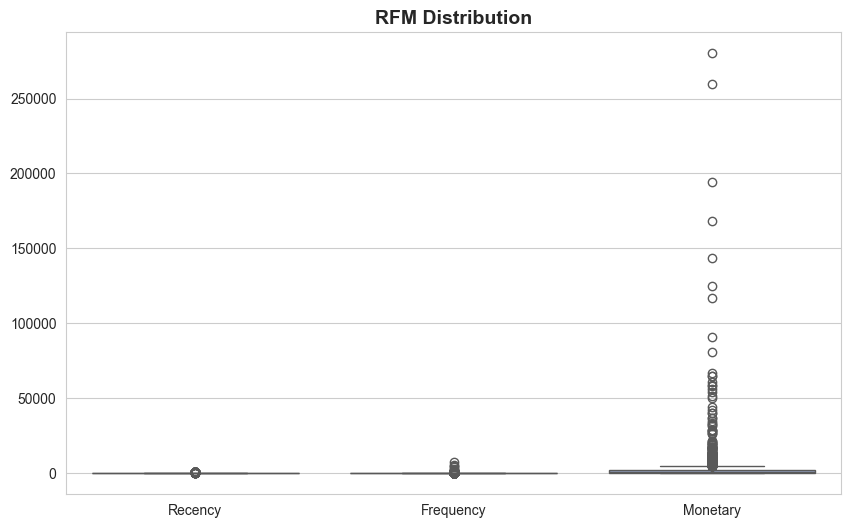

In [ ]:
plt.figure()
sns.boxplot(data=RFM[['Recency','Frequency','Monetary']],palette='Set2')
plt.title("RFM Distribution", fontsize=14,weight='bold')
plt.show()

Customer Segment Distribution chart

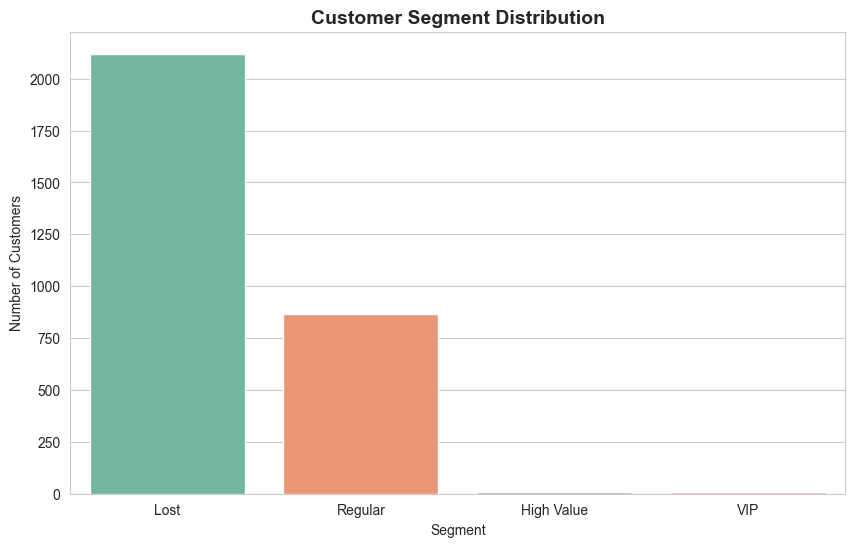

In [58]:
plt.figure()
sns.countplot(
    data=RFM,
    x='Segment',
    hue='Segment',
    palette='Set2')
plt.title("Customer Segment Distribution", fontsize=14, weight='bold')
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

##  Business Recommendations
- Retain VIP customers using loyalty programs
- Target high-value customers with personalized offers
- Encourage regular customers to buy more
- Re-engage lost customers with discounts or campaigns